In [2]:
import pandas as pd

def read_graph_parquet(filepath: str) -> pd.DataFrame:
    """
    Lê um arquivo .parquet com colunas:
      - nodes
      - neighbors
      - degree

    Retorna um pandas.DataFrame.
    """
    df = pd.read_parquet(filepath, engine="pyarrow")
    return df

In [3]:
df = read_graph_parquet("../build/NET_data/raw/N_200000/alpha_0.500/light_seed_1_ts_20260324T195741.parquet")
df
# print(df.head())
# print(df.columns)
# print(df.iloc[0]["nodes"])
# print(df.iloc[0]["neighbors"])
# print(df.iloc[0]["degree"])

,nodes,neighbors,degree
0,0,"[1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 1...",1567
1,1,"[0, 2, 3, 4, 5, 6, 10, 11, 12, 16, 20, 22, 24,...",1429
2,2,"[0, 1, 3, 4, 5, 6, 8, 9, 11, 12, 13, 14, 16, 3...",688
3,3,"[0, 1, 2, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 1...",1474
4,4,"[0, 1, 2, 3, 5, 6, 8, 9, 10, 13, 14, 16, 19, 2...",1356
...,...,...,...
199995,199995,[90654],1
199996,199996,[85496],1
199997,199997,[96304],1
199998,199998,"[51097, 129046]",2


1.0000000000000002


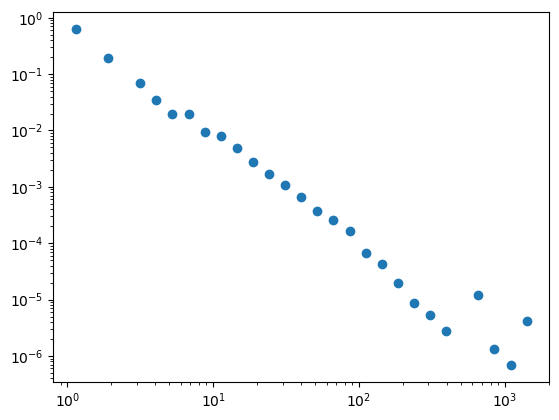

29

In [10]:
import matplotlib.pyplot as plt
import numpy as np
degree = np.sort(df['degree'])
MIN_VAL = np.min(degree)
MAX_VAL = np.max(degree)
num_bins = 30 # Or any desired number of bins
# Create bins using np.logspace, specifying the start/stop as log10 of min/max
log_bins = np.logspace(np.log10(MIN_VAL), np.log10(MAX_VAL), num_bins)
pk, k_edges = np.histogram(degree, bins=log_bins, density=True)
k = 0.5 * (k_edges[:-1] + k_edges[1:])
pk = pk / pk.sum()
print(sum(pk))
plt.plot(k,pk,'o')
plt.xscale("log")
plt.yscale("log")
plt.show()

len(pk)

#plt.hist(df['degree'],density=True)
#plt.show()